# Logistic Regression from Scratch: Gradient Descent on the Titanic Dataset

This notebook reimplements logistic regression example from Part 1, but instead of calling `LogisticRegression().fit()`,
we derive and implement **gradient descent** by hand.

We will:
1. Load and preprocess the Titanic dataset.
2. Review the mathematical foundations of logistic regression.
3. Implement gradient descent to learn the model weights.
4. Compare our results against scikit-learn.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 1. Data Loading and Preprocessing

In [2]:
data = pd.read_csv("../data/titanic.csv")
data.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [3]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"
numerical_cols = ['age', 'fare', 'family_size']

features = data[FEATURES]
target = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=81842, stratify=target
)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


## 2. Feature Standardization

Gradient descent converges much faster when features are on a similar scale.
We standardize each feature to have zero mean and unit variance:

$$
x_j^{\prime} = \frac{x_j - \mu_j}{\sigma_j}
$$

We fit the statistics on the **training set only** and apply them to both sets
to avoid data leakage.

In [4]:
# TODO: Implement feature standardization.
print(f"X_train before scaling:\n{X_train.head()} \n")

X_train_np_numerical = X_train[numerical_cols].to_numpy()
means = np.mean(X_train_np_numerical, axis=0)
stds = np.std(X_train_np_numerical, axis=0)
print(f"Means: {means}")
print(f"Stds: {stds}")

X_train[numerical_cols] = (X_train[numerical_cols] - means) / stds
print(f"X_train after scaling:\n{X_train.head()} \n")

###############
X_test_np_numerical = X_test[numerical_cols].to_numpy()
X_test_scaled = (X_test_np_numerical - means) / stds

X_test_final = X_test.copy()
X_test_final[numerical_cols] = X_test_scaled

X_test_s = X_test_final.to_numpy()

X_train before scaling:
     sex   age  family_size     fare  1st_class  2nd_class  3rd_class
109    1  47.0            0  52.0000          1          0          0
154    1  51.0            1  61.3792          1          0          0
253    0  41.0            2  20.2125          0          0          1
126    1  24.0            0   7.1417          0          0          1
690    1  25.0            0   7.2250          0          0          1 

Means: [29.66973202 31.59254133  0.89280677]
Stds: [13.97011217 46.99125217  1.63350554]
X_train after scaling:
     sex       age  family_size      fare  1st_class  2nd_class  3rd_class
109    1  1.240525    -0.546559  0.434282          1          0          0
154    1  1.526850     0.065622  0.633877          1          0          0
253    0  0.811036     0.677802 -0.242174          0          0          1
126    1 -0.405847    -0.546559 -0.520328          0          0          1
690    1 -0.334266    -0.546559 -0.518555          0          0    

## 3. Mathematical Background

### 3.1 The Logistic (Sigmoid) Function

In logistic regression we model the probability that a sample belongs to the
positive class ($y = 1$) using the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

where the linear combination (logit) is:

$$
z = \mathbf{w}^\top \mathbf{x} + b = \sum_{j=1}^{d} w_j x_j + b
$$

Here $\mathbf{w} \in \mathbb{R}^d$ is the weight vector, $b \in \mathbb{R}$ is
the bias (intercept), and $d$ is the number of features.

The sigmoid function maps any real-valued input to a value between 0 and 1. 
We will use it to transform the model’s raw output (which can be any real number) into a probability. 
Large positive numbers are mapped close to 1, large negative numbers are mapped close to 0. 
This makes it suitable for binary classification.

The predicted probability is therefore:

$$
\hat{y} = P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

The model computes a weighted sum of the input features and adds a bias term. 
This linear combination represents how strongly the input features support one class over the other. 
The sigmoid function then converts this value into a probability.

For example, a value of 0.8 means that the model estimated an 80% chance that the input belongs to the positive class.

### 3.2 Binary Cross-Entropy Loss

We measure how well the model fits the training data using the
**binary cross-entropy** (log loss), averaged over $n$ samples:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
  y^{(i)} \ln\!\big(\hat{y}^{(i)}\big)
  + \big(1 - y^{(i)}\big) \ln\!\big(1 - \hat{y}^{(i)}\big)
\right]
$$

This loss is **convex** in $\mathbf{w}$ and $b$, so gradient descent is
guaranteed to find the global minimum.

The loss function measures how well the model predictions (the probabilities) match the true labels.  
Binary cross-entropy penalizes confident but incorrect predictions more heavily than uncertain ones.
If the model predicts a probability close to the true label, the loss is small, otherwise the loss increases rapidly.

### 3.3 Gradient Derivation

To compute how the loss changes with respect to the model parameters, gradients tell us in which direction we need to adjust the parameters to reduce the loss.

If the predictions are too high, this will lead to gradients with positive values. 
If predictions are too low, this will lead to gradients with negative values. 
The magnitude depends on how large the error is and the value of the input features.

To minimize $\mathcal{L}$ we need the partial derivatives with respect to each weight $w_j$ and the bias $b$.

Using the chain rule and the identity
$\sigma'(z) = \sigma(z)(1 - \sigma(z))$, the gradients simplify to:

$$
\frac{\partial \mathcal{L}}{\partial w_j}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)\, x_j^{(i)}
$$

$$
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \sum_{i=1}^{n}
  \big(\hat{y}^{(i)} - y^{(i)}\big)
$$

Or in compact vector notation, with
$\hat{\mathbf{y}} = \sigma(X\mathbf{w} + b)$:

$$
\nabla_{\mathbf{w}} \mathcal{L}
= \frac{1}{n} X^\top (\hat{\mathbf{y}} - \mathbf{y})
\qquad\qquad
\frac{\partial \mathcal{L}}{\partial b}
= \frac{1}{n} \mathbf{1}^\top (\hat{\mathbf{y}} - \mathbf{y})
$$

### 3.4 Gradient Descent Update Rule

We iteratively update the parameters using a learning rate $\alpha$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha\, \nabla_{\mathbf{w}} \mathcal{L}
$$

$$
b \leftarrow b - \alpha\, \frac{\partial \mathcal{L}}{\partial b}
$$

At each step, the model updates the parameters slightly to reduce loss. Over many iterations, this leads to a set of parameters that fit the data well.

The learning rate $\alpha$ determines how large the update step is when adjusting the model parameters during training. 
Small learning rates (e.g. $\alpha = 0.001$) are slow but stable, whereas large learning rates ($\alpha = 0.1$) are fast, but may cause instabilities and training may fail completely.

We repeat until convergence (i.e., until the loss changes by less than a pre-defined tolerance $\varepsilon$), or if a maximum number of iterations is reached.

## 4. Implementation

Now it's time to implement the algorithm.
You need to account for numerical stability to ensure that the algorithm's returned results are sound.

In [5]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """A numerically stable sigmoid function."""
    # TODO: Implement this function.
    return 1 / (1 + np.exp(-z))
    # return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


def binary_cross_entropy(y: np.ndarray, y_hat: np.ndarray) -> float:
    """Compute the mean binary cross-entropy loss.

    Take care in your implementation to ensure that the cross entropy is always positive,
    and that it stays stable for very small probabilities (y_hat \approx 0).
    """
    # TODO: Implement this function.
    # return -np.mean(y * np.log(y_hat + 1e-15) + (1 - y) * np.log(1 - y_hat + 1e-15))
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)
    return float(-np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)))

def pred(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    # return np.array([sigmoid(x.dot(w) + b) for x in X])
    return sigmoid(np.dot(X, w) + b)

def logistic_regression_gd(
    X: np.ndarray,
    y: np.ndarray,
    lr: float = 0.1,
    max_iter: int = 1000,
    tol: float = 1e-6,
) -> tuple[np.ndarray, float, list[float]]:
    """Train logistic regression via gradient descent.

    Returns (weights, bias, loss_history).
    """
    n_samples, n_features = X.shape
    w = np.zeros((n_features, 1))
    b = 0.0
    loss_history = []

    # TODO: Implement this function.
    for iter in range(max_iter):
        Z = np.dot(X, w) + b
        A = sigmoid(Z)

        dw = np.dot(X.T, (A - y)) / n_samples
        db = np.sum(A - y) / n_samples # mean ?

        w = w - lr * dw
        b = b - lr * db

        loss = binary_cross_entropy(y, A)
        loss_history.append(loss)

        # if iter > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
        #     break
        if iter == 0:
            continue
        diff = loss_history[-1] - loss_history[-2]
        if diff > 0:
            print("Warning: Loss is increasing. Try a smaller learning rate.")
            break
        if abs(diff) < tol:
            print(f"Converged at iteration {iter}")
            break
    # print(w.flatten(), b, loss_history)
    return w, b, loss_history

## 5. Training

In [6]:
# Train our model on the standardized features

# ?
X_train_s = X_train.to_numpy()
y_train = y_train.to_numpy().reshape(-1, 1)
# ?
w, b, loss_history = logistic_regression_gd(X_train_s, y_train, lr=0.1, max_iter=1000)

print(type(w), type(b), type(loss_history))
print(type(w[0][0]))

print(f"Final loss: {loss_history[-1]:.6f}")
print(f"Iterations: {len(loss_history)}")
print(f"\nLearned weights:")
for name, weight in zip(FEATURES, w):
    print(f"  {name:>30s}: {weight[0]:+.4f}")
print(f"  {'bias':>30s}: {b:+.4f}")

<class 'numpy.ndarray'> <class 'numpy.float64'> <class 'list'>
<class 'numpy.float64'>
Final loss: 0.454884
Iterations: 1000

Learned weights:
                             sex: -2.4232
                             age: -0.4439
                     family_size: -0.3904
                            fare: +0.1955
                       1st_class: +1.2613
                       2nd_class: +0.3577
                       3rd_class: -0.6516
                            bias: +0.9673


### Loss Curve

A decreasing loss curve confirms that gradient descent is working correctly.

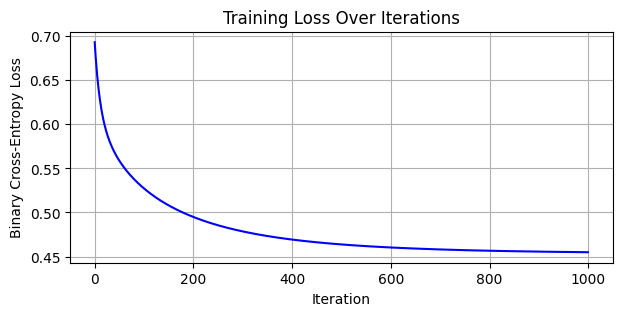

In [7]:
import matplotlib.pyplot as plt

# TODO: Implement a loss curve plot.
plt.figure(figsize=(7, 3))

plt.plot(loss_history, color='blue', label='Training Loss')

plt.title("Training Loss Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")

plt.grid(True)
plt.show()

## 6. Evaluation

We classify a sample as positive ($\hat{y} = 1$) when $\sigma(z) \geq 0.5$,
which is equivalent to $z \geq 0$.

In [8]:
def predict(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    """Predict class labels (0 or 1)."""
    # TODO: Implement this function.
    linear_model = np.dot(X, w) + b
    y_predict = sigmoid(linear_model)
    return (y_predict >= 0.5).astype(int)


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute classification accuracy."""
    # TODO: Implement this function.
    return np.mean(y_true.flatten() == y_pred.flatten())


# Evaluate on train and test sets
y_pred_train = predict(X_train_s, w, b)
y_pred_test = predict(X_test_s, w, b)

print(f"Our model — Train accuracy: {accuracy(y_train, y_pred_train):.4f}")
print(f"Our model — Test accuracy:  {accuracy(y_test.to_numpy(), y_pred_test):.4f}")

Our model — Train accuracy: 0.7941
Our model — Test accuracy:  0.8483


## 7. Comparison with scikit-learn

We train the same model using scikit-learn's `LogisticRegression` (with the
same standardized data) to verify that our gradient descent implementation
arrives at comparable accuracy and weights.

In [9]:
# scikit-learn logistic regression (no regularization, to match our implementation)
sk_model = LogisticRegression(max_iter=1000, random_state=42, C=np.inf)
sk_model.fit(X_train_s, y_train)

sk_accuracy = sk_model.score(X_test_s, y_test)
our_accuracy = accuracy(y_test.to_numpy(), y_pred_test)

print(f"scikit-learn test accuracy: {sk_accuracy:.4f}")
print(f"Our GD test accuracy:      {our_accuracy:.4f}")
print()
 
# Compare learned weights
print(f"{'Feature':>30s} | {'Ours':>8s} | {'sklearn':>8s}")
print("-" * 55)
for name, w_ours, w_sk in zip(FEATURES, w, sk_model.coef_[0]):
    print(f"{name:>30s} | {w_ours[0]:+8.4f} | {w_sk:+8.4f}")
print(f"{'bias':>30s} | {b:+8.4f} | {sk_model.intercept_[0]:+8.4f}")

scikit-learn test accuracy: 0.8483
Our GD test accuracy:      0.8483

                       Feature |     Ours |  sklearn
-------------------------------------------------------
                           sex |  -2.4232 |  -2.6755
                           age |  -0.4439 |  -0.5081
                   family_size |  -0.3904 |  -0.4151
                          fare |  +0.1955 |  +0.1012
                     1st_class |  +1.2613 |  +1.5441
                     2nd_class |  +0.3577 |  +0.3311
                     3rd_class |  -0.6516 |  -0.7534
                          bias |  +0.9673 |  +1.1217


/Users/YuriiButkov/Documents/MLOps/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/YuriiButkov/Documents/MLOps/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Summary

We implemented logistic regression from scratch using gradient descent and
verified it against scikit-learn. Key takeaways:

- The **sigmoid function** maps any real number to a probability in $(0, 1)$.
- The **binary cross-entropy loss** is convex, so gradient descent finds the
  global optimum.
- **Feature standardization** is critical for gradient descent to converge
  efficiently — without it, features on very different scales (e.g., Age vs.
  Fare) cause the loss surface to be poorly conditioned.
- Our hand-rolled implementation reaches the same accuracy and learns
  nearly identical weights as scikit-learn's optimized solver.